In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
pip install pyspark

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.4/281.4 MB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 KB 16.6 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.3.1-py2.py3-none-any.whl size=281845512 sha256=f0b02378cc7e1694aad1b6a3ac7f21dd7971904ed83d74e798cbebc96929492a
  Stored in directory: /root/.cache/pip/wheels/43/dc/11/ec201cd671da62fa9c5cc77078235e40722170ceba231d7598
Successfully built pyspark


# Working with Spark DataFrames
When it comes to all the strucutured APIs in Spark, the DataFrames API is probably the most commonly used way to 
interact with Spark functionality because its most familiar with most users. In this notebook, we will dive deeper into the DataFrames 
API and explore the following topics:
- Creating Spark DataFrames with Schema and the advantage of using schemas
- Manipulating DataFrames (e.g., adding colummns, renaming columns, changing data types etc
- Query DataFrames. How do you filter data?
- Performing common data analysis tasks on DataFrames (e.g., grouping data, applying functions)
- Applying user defined functions in Spark DataFrames
- Switching between DataFrames and other data structures (e.g., Pandas, RDD's etc)

## Python setup

In [ ]:
from pathlib import Path
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
import pandas as pd
from functools import wraps
import time
from IPython.display import Image
from datetime import datetime
from multiprocessing import Pool

## Inputs setup
Lets provide paths to input files we will use. 
Its a good practice to create these as global variables. Also, use Python module ```Path``` from pathlib to manage file paths. 

In [ ]:
# Altenatively, you can put a full-path to wheree your data is located like below
# DATA_DIR = Path(full-path-folder-where-you-are-keeping-data)
DATA_DIR = Path().cwd().parents[0].joinpath("DATA")


# Path to any large CSV file (e.g., activity_log_raw,csv)
LARGE_CSV = Path().cwd().parents[2].joinpath("WBG-LOCAL/MADAGASCAR-POV-MAPPING/data/input/census/data/ResidentIBEIPM.csv")

# Activity_log_raw
ACTIV_LOG = DATA_DIR.joinpath("raw", "activity_log_raw.csv")

# path to hh_data.txt
HH_DATA = DATA_DIR.joinpath("raw", "hh_data.txt")

# word_count_files folder
# in your data folder, create a word_count_files folder
WORD_COUNT = DATA_DIR.joinpath("raw", "word_count_files")

IndexError: ignored

## Composition of a Spark DataFrame
In Spark, a DataFrame object consists of [Row](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.Row.html) objects and [Column](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.Column.html) objects. Concretely, each row of a Spark DataFrame  is an instance of the ```pyspark.sql.Row``` while each column is an instance of the ```pyspark.sql.Column``` class. We will look at  each of these classes in detail.

## Creating DataFrames
There are three main ways to create a Spark DataFrame as follows:
1. From Python objects
2. External data sources
3. Other Spark objects

### Schemas
Also, when creating DataFrames, you have the option to use a schema or not. A schema in Spark defines the column names and associated data types for a DataFrame. Most often, schemas come into play when you are reading structured data from an external data source. When a schema is not used, Spark has to infer the data type which can slow your application if you have a massive  dataset. Although schemas are more of DBMS language but they offer several advantages when dealing with large datasets:
- Spark doesnt have to infer data types, so you get speed benefits.
- Without a schema, Spark creates a separate job just to read a large portion of your file to ascertain the schema, which for a large data file can be expensive and time-consuming. As such, defining a schema will avoid this.
- You can detect errors early if data doesn’t match the schema.
#### Defining Schemas
- Programmatically using Spark DataTypes 
- Using Data Definition Language (DDLs)

### Spark DataFrame from Python objects
Given a list of data (in most cases its going to be a nested list), how do we convert it into a Spark DataFrame. There are several depending on the input Pytho objects. Here are some:
1. Define a schema for the new dataframe. The schema helps Spark understand the column data types
2. Convert the regular Python objects into ```Rows``` which we can the use to create a DataFrame

In [ ]:
# initialize SparkSession
spark = SparkSession.builder.master("local[*]").appName("DataFrameFromPythonObj").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


23/02/13 19:25:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
23/02/13 19:25:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
23/02/13 19:25:34 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
23/02/13 19:25:34 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
23/02/13 19:25:34 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


In [ ]:
# The data 
data = [[1, "Jules", "Damji", "https://tinyurl.1", "1/4/2016", 4535, ["twitter","LinkedIn"]],
           [2, "Brooke","Wenig", "https://tinyurl.2", "5/5/2018", 8908, ["twitter",
    "LinkedIn"]],
           [3, "Denny", "Lee", "https://tinyurl.3", "6/7/2019", 7659, ["web",
    "twitter", "FB", "LinkedIn"]],
           [4, "Tathagata", "Das", "https://tinyurl.4", "5/12/2018", 10568,
    ["twitter", "FB"]],
           [5, "Matei","Zaharia", "https://tinyurl.5", "5/14/2014", 40578, ["web",
    "twitter", "FB", "LinkedIn"]],
           [6, "Reynold", "Xin", "https://tinyurl.6", "3/2/2015", 25568,
    ["twitter", "LinkedIn"]]
          ]
# examine the data 
data[0]

[1,
 'Jules',
 'Damji',
 'https://tinyurl.1',
 '1/4/2016',
 4535,
 ['twitter', 'LinkedIn']]

In [ ]:
# Define schema for our data using DDL, in most cases whe 
schema_twitter = "num INT, first_name STRING, last_name STRING, url STRING, date STRING, some_num INT, tweet STRING"

In [ ]:
# Create a DataFrame using the schema defined above
sdf_python_obj_schema = spark.createDataFrame(data, schema=schema_twitter)
print(sdf_python_obj_schema.printSchema())

root
 |-- num: integer (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- url: string (nullable = true)
 |-- date: string (nullable = true)
 |-- some_num: integer (nullable = true)
 |-- tweet: string (nullable = true)

None


In [ ]:
# Convert list of items into Spark Rows
spark_rows = []

for item in data:
    row = Row(num=item[0], first_name=item[1], last_name=item[2], 
              url=item[3], date=item[4], some_num=item[5], tweet=item[6])
    spark_rows.append(row)

In [ ]:
sdf_from_rows = spark.createDataFrame(spark_rows)

In [ ]:
sdf_from_rows.show()

+---+----------+---------+-----------------+---------+--------+--------------------+
|num|first_name|last_name|              url|     date|some_num|               tweet|
+---+----------+---------+-----------------+---------+--------+--------------------+
|  1|     Jules|    Damji|https://tinyurl.1| 1/4/2016|    4535| [twitter, LinkedIn]|
|  2|    Brooke|    Wenig|https://tinyurl.2| 5/5/2018|    8908| [twitter, LinkedIn]|
|  3|     Denny|      Lee|https://tinyurl.3| 6/7/2019|    7659|[web, twitter, FB...|
|  4| Tathagata|      Das|https://tinyurl.4|5/12/2018|   10568|       [twitter, FB]|
|  5|     Matei|  Zaharia|https://tinyurl.5|5/14/2014|   40578|[web, twitter, FB...|
|  6|   Reynold|      Xin|https://tinyurl.6| 3/2/2015|   25568| [twitter, LinkedIn]|
+---+----------+---------+-----------------+---------+--------+--------------------+



### Rows
A row in Spark is a generic Row object, containing one or more columns. Each column may be of the same data type (e.g., integer or string), or they can have different types (integer, string, map, array, etc.). 
Because Row is an object in Spark and an ordered collection of fields, you can instantiate a Row the same way we instantiate any object. Consequently, you can collect Row objects in a list and create a Spark DataFrame.

In [ ]:
# import row class
from pyspark import Row

first_five_rows = sdf.head(5)
type(first_five_rows[0])

# create row 
row = Row(name="Alice", age=11)

# A list of rows 
rows = [Row(name="Matei Zaharia", state="CA"), Row(name="Reynold Xin", state="CA")]

# Create a DataFrame from Row objects
spark_df_from_rows = spark.createDataFrame(rows)
spark_df_from_rows.show()

+-------------+-----+
|         name|state|
+-------------+-----+
|Matei Zaharia|   CA|
|  Reynold Xin|   CA|
+-------------+-----+



**EXERCISE-1:** Creating a Spark DataFrame with Rows. Please complete the function below and call it.

In [ ]:
def convert_json_to_spark_with_rows(json_file):
    # create  a list to hold all Row objects
    rows = YOUR CODE
    for idx, row in df.iterrows():
        # get lon and lat from the coord column using indexing, dict key access
        x = row['coord']['lon']       
        y = row['coord']['lat']
        # create the Row object here 
        srow = YOUR CODE
        
        # append this row object to the list
        YOUR CODE
    
    # When creating Spark DataFrame this way, its better to use schema to avoid troubles
    # create a schema for this data here, use DOUBLE as data type for lon and lat
    schema = YOUR CODE
    
    # use spark.createDataFrame() here
    # if yiu get errors, use the option verifySchema=False
    spark_df = YOUR CODE
    
    # use show() statement to show the DataFrame
    # use show() with print to ensure we see the outputs
    YOUR CODE

In [ ]:
jsonfile = str(DATA_DIR.joinpath("raw", "city.list.json")
#convert_json_to_spark_with_rows(jsonfile)
df.show()

**EXERCISE-2: READ CSV WITH SCHEMA**
1. Use Spark documentation on how to read from file with a define schema. 
Note, the schema is what we arleady defined above. The data above has been saved as ```blog_simple_dataset.csv```. Read it as a Spark DataFrame with schema. Answer this question in the next cell.
2. Define schema for the ```activity_raw_data.csv``` use string for the datetime column
3. Load the dataset with and without schema using the functions defined below. Compare the loading times. Answer this question by completing the functions defined below and calling them.

In [ ]:
def timefn(fn):
    """
    Function for recording running time of a function
    """
    @wraps(fn)
    def measure_time(*args, **kwargs):
        t1 = time.time()
        result = fn(*args, **kwargs)
        t2 = time.time()
        print("@timefn:" + fn.__name__ + " took " + str(t2 - t1) + " seconds")
        return result
    return measure_time

In [ ]:
@timefn
def load_with_schema(large_csv):
    # define the schema here using DDL
    # you can load part of the file with pandas (just a few rows)
    # to remind yourself of the data types
    schema = "`SID` INT, `ACTIVITY_ID` INT, `Last` STRING, `ACTIVITY_TIME` STRING,`STATUS` STRING"
    spark = SparkSession.builder.master("local[*]").appName("ReadWithChema").getOrCreate()
    # Now read the data 
    sdf = spark.read.schema(schema).csv(large_csv)
    
    print(sdf.show())

In [ ]:
@timefn
def load_without_schema(large_csv):
    spark = SparkSession.builder.master("local[*]").appName("DataFrameFromPythonObj").getOrCreate()
    sdf = spark.read.csv(large_csv, header=True)
    print(sdf.show())

In [ ]:
load_with_schema(str(ACTIV_LOG))

+----+-----------+--------------------+-------------+------+
| SID|ACTIVITY_ID|                Last|ACTIVITY_TIME|STATUS|
+----+-----------+--------------------+-------------+------+
|null|       null|       ACTIVITY_TIME|       STATUS|  null|
| 584|       1291|13-APR-15 10.33.4...|            S|  null|
| 584|       1286|13-APR-15 10.33.4...|            S|  null|
| 584|       1285|13-APR-15 10.33.4...|            S|  null|
| 584|       1284|13-APR-15 10.33.4...|            S|  null|
| 584|       1288|13-APR-15 10.33.4...|            S|  null|
| 584|       1293|13-APR-15 10.33.4...|            S|  null|
| 344|         10|13-APR-15 10.33.3...|            N|  null|
| 344|         10|13-APR-15 10.33.3...|            R|  null|
| 344|         10|13-APR-15 10.33.3...|            N|  null|
| 584|       1269|13-APR-15 10.33.2...|            S|  null|
| 584|       1268|13-APR-15 10.33.2...|            S|  null|
| 584|       1267|13-APR-15 10.33.2...|            S|  null|
| 584|       1266|13-APR

In [ ]:
load_without_schema(str(ACTIV_LOG))

+---+-----------+--------------------+------+
|SID|ACTIVITY_ID|       ACTIVITY_TIME|STATUS|
+---+-----------+--------------------+------+
|584|       1291|13-APR-15 10.33.4...|     S|
|584|       1286|13-APR-15 10.33.4...|     S|
|584|       1285|13-APR-15 10.33.4...|     S|
|584|       1284|13-APR-15 10.33.4...|     S|
|584|       1288|13-APR-15 10.33.4...|     S|
|584|       1293|13-APR-15 10.33.4...|     S|
|344|         10|13-APR-15 10.33.3...|     N|
|344|         10|13-APR-15 10.33.3...|     R|
|344|         10|13-APR-15 10.33.3...|     N|
|584|       1269|13-APR-15 10.33.2...|     S|
|584|       1268|13-APR-15 10.33.2...|     S|
|584|       1267|13-APR-15 10.33.2...|     S|
|584|       1266|13-APR-15 10.33.2...|     S|
|584|       1265|13-APR-15 10.33.2...|     S|
|584|       1264|13-APR-15 10.33.2...|     S|
|584|       1263|13-APR-15 10.33.2...|     S|
|584|       1262|13-APR-15 10.33.2...|     S|
|584|       1261|13-APR-15 10.33.2...|     S|
|584|       1260|13-APR-15 10.33.2

<div class="alert alert-info"> 
The difference shown above will of course become signficant and consequential when the number of columns and size of data increase. As such =, although not required, in some use cases, you can use schema to improve performance.
</div>

### Spark DataFrame from external data sources
The most common way (which we have already seen) is to load data from exteernal data sources and 
Spark supports numerous data stores. Spark reads data  through the ```DataFrameReaderobject```. Please look at the documeentation [here](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.DataFrameReader.csv.html) to see all data sources that the Spark  ```DataFrameReaderobject``` supports.

## Manipulating Spark DataFrames 

### Columns and Expressions in  DataFrames
In Spark DataFrames, columns behave like pandas DataFrames in several ways but they also behave different. You can list all the columns by their names, and you can perform operations on their values using relational or computational expressions. 
- [Column](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.Column.html) is the name of the object, which has many import methods such as describe  while [col()](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.sql.functions.col.html) is a standard built-in function that returns a Column.

We need to use the col() and expr() function available in pyspark,sql.functions() for many operations such as:
- Add, rename columns
- Subset data based on columns
- Access columns to compute stats on them
- Access columns to compute operations on them such as sorting

In [ ]:
# Lets use Activity_log_raw.csv for trying out manipulations
sdf = spark.read.csv(str(ACTIV_LOG), header=True)

### Selecting columns and rows 
How to select a single column and/or a subset of rows. We use ```select()``` to pick one or multipe. 
However, some of the same indexing we use in Pandas work, 

In [ ]:
# Find unnique values in column 'P21'
# Note that you have to use colleect() or show() 
# to bring results to driver and see, other this is a transformation
sdf2 = sdf.select('ACTIVITY_TIME', 'STATUS')
sdf2.show()

+--------------------+------+
|       ACTIVITY_TIME|STATUS|
+--------------------+------+
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.3...|     N|
|13-APR-15 10.33.3...|     R|
|13-APR-15 10.33.3...|     N|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
|13-APR-15 10.33.2...|     S|
+--------------------+------+
only showing top 20 rows



In [ ]:
# Use of the Pandas like indexing seem to also be supported like this 
# but just experiment with it because not everything is supported 
sdf_two_cols = sdf[['ACTIVITY_TIME', 'STATUS']]
sdf_two_cols.show(5)

+--------------------+------+
|       ACTIVITY_TIME|STATUS|
+--------------------+------+
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
|13-APR-15 10.33.4...|     S|
+--------------------+------+
only showing top 5 rows



### Add a new column using expr and col
In order to add a new column in a Spark DataFrame, we use the ```DataFrame.withColumn(new_col_name, expression_to_compute_new_col)```. 
For that, we need to import the ```col``` and ```expr``` functions from the ```pyspark.sql.functions``` module.

In [ ]:
# use expr
sdf2 = sdf.withColumn("new_col", (expr("ACTIVITY_ID > 10000")))
sdf2.show()

In [ ]:
# use the col function which I prefer over the expr col("Hits")
sdf2 = sdf.withColumn("new_col", col("ACTIVITY_ID") > 10000)
sdf2.show()

**EXERCISE-3:**

1. Check  if these statements: df.select(expr("ACTIVITY_TIME")).show(2), df.select(col("ACTIVITY_TIME")).show(2)
and df.select("ACTIVITY_TIME").show(2) will provide  the same output. Replace df with name of your Spark DataFrame.

2. Create a new DataFrame using expr to get only those rows where STATUS is "S"
Note that expr() just perfoms the operation, it doesnt filter our the rows which evaluate to false.
2. Sort DataFrame: use the col function to sort the DataFrame on "SID" column

**EXERCISE-4: USING THE HH_DATA, TRY OUT THESE COMMON OPERATIONS ON A DATAFRAME**
1. Using the ```filter()``` function create a DataFrame of people who are 5 years and younger?
2. Find household size using ```groupby()``` on the hh_id column and appropriate function (e.g., count, avg)
3. Rename columns as follows: ```P08-->age```, ```P07M-->dob_month``` and ```P07A-->dob_yr```
4. Find how many null values are there in the age column and drop all nulls in the DataFrame

## Spark-SQL functions
As usual refer to the Pyspark API documentation for an overview of spark modules and core classes. So far, we have been 
interacting with spark-SQL. Within the spark-SQL, we have worked with the following:
- DataFrame API
- Row
- Spark Session API
- Functions

For functions, we have only used simple functions such as ```count``` and ```avg``` used in aggregation. Now, lets look at user defined functions (udf). Although new and more functions are continuously being added to the spark APIs, you will often find yourself in a situation where you need to define a small Python function to apply on spark DataFrame or other data types in spark.

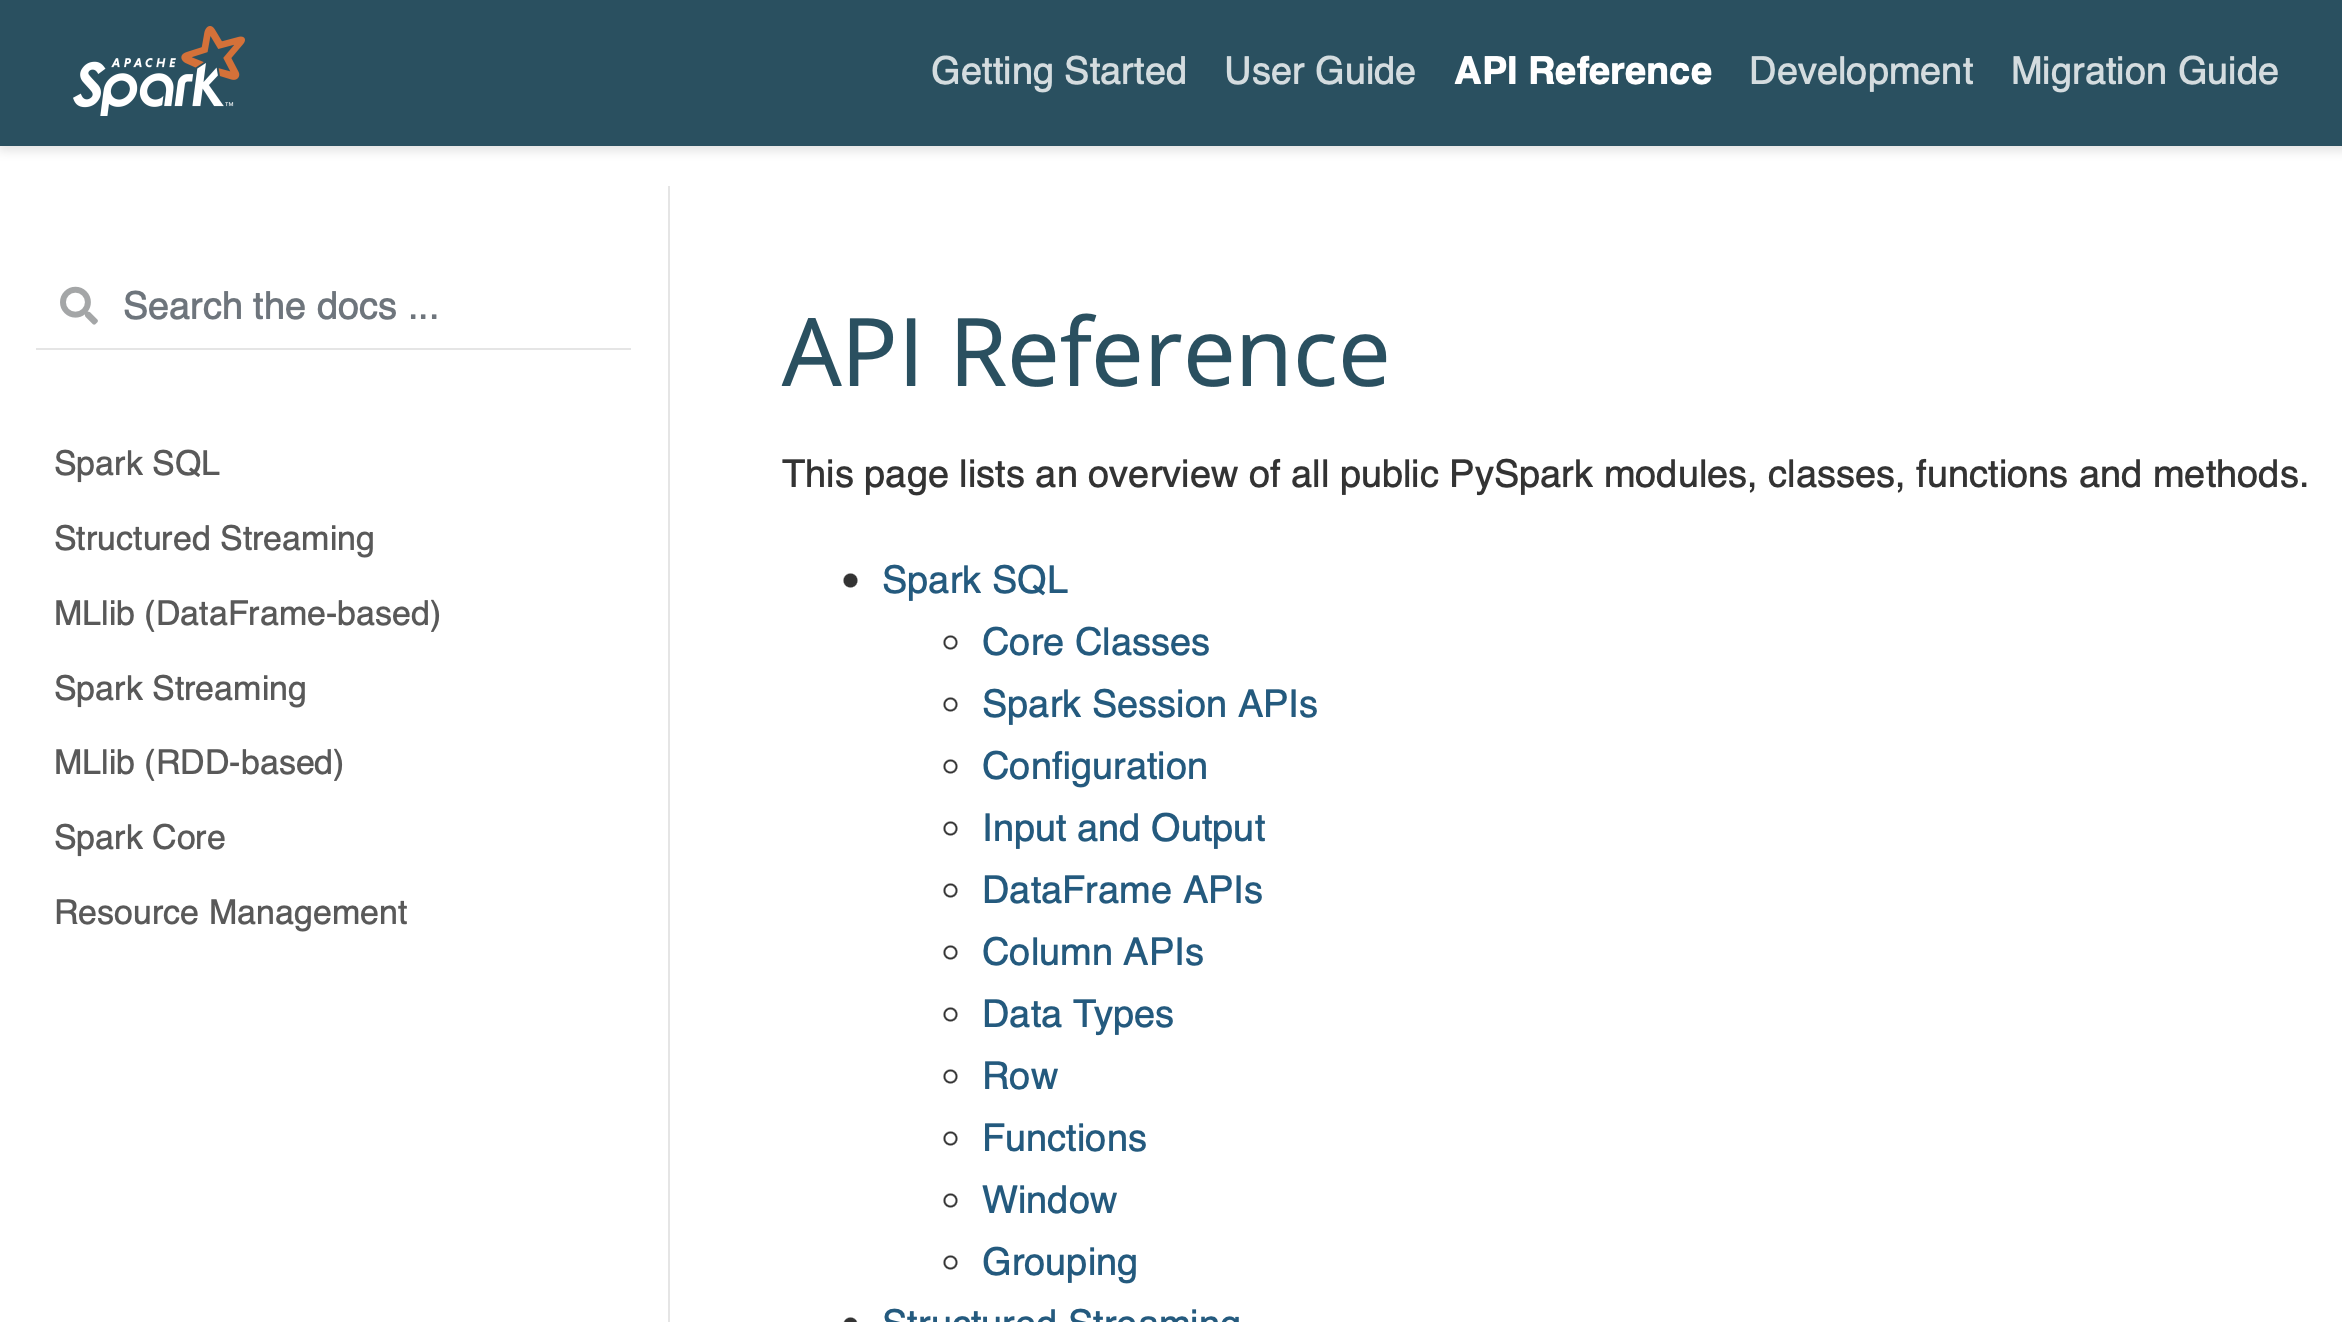

In [ ]:
Image("../DOCS/images/spark-functions.png", width=700)

### Creating and using user defined functions

In [ ]:
# Use Spark UDF to add date and datetime


In [ ]:

date_format='%Y%m%d%H%M%S'

# create timestamp
df3 = df2.withColumn('datetime', add_datetime(col('cdr_datetime')))
df4 = df3.withColumn('date', add_date(col('cdr_datetime')))

In [ ]:
# Exercise: Try outt UDF on the activity_log_raw file
sdf = spark.read.csv(CSV_PATH, header=True)